In [1]:
import torch
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoConfig,
    BitsAndBytesConfig,
    DataCollatorForLanguageModeling,
    DataCollatorWithPadding,
)

from peft import (
    prepare_model_for_kbit_training,
    get_peft_model,
    LoraConfig
)

from trl import (
    SFTTrainer,
    SFTConfig,
    apply_chat_template,      # replaces setup_chat_format
    pack_dataset,             # replaces ConstantLengthDataset
    get_kbit_device_map,      # bonus: useful for quantization
)

In [3]:
repo_id = "microsoft/phi-3-mini-4k-instruct"
tokenizer_phi = AutoTokenizer.from_pretrained(repo_id)
config_phi = AutoConfig.from_pretrained(repo_id, trust_remote_code=True)

A new version of the following files was downloaded from https://huggingface.co/microsoft/phi-3-mini-4k-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


In [4]:
tokenizer_phi("Let's tokenize this sentence!")

{'input_ids': [2803, 29915, 29879, 5993, 675, 445, 10541, 29991], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}

## Vocabulary

## tokenizer’s vocabulary is the exhaustive list of every possible token a modern can handle 

Andrej Karpathy (Feb 2023) said: embedding layers work best when their size is a multiple of a power of two—e.g., 50,304 ✅ is better than 50,257 ❌.

So, most, if not all, models nowadays have embedding layers longer than what is actually required by the
corresponding vocabulary.

people appended "empty slots" to the embedding layers of older models
to get the benefit of improved performance without having to train anything.

In [6]:
len(tokenizer_phi), config_phi.vocab_size

(32011, 32064)

len(tokenizer_phi) This gives the number of tokens the tokenizer can produce 

config_phi.vocab_size → This is the embedding layer size in the model config. It tells the model how many embeddings it expects.

32,011? No good! 32,064? It is awesome because it’s a multiple of 32 (2 to the fifth power).

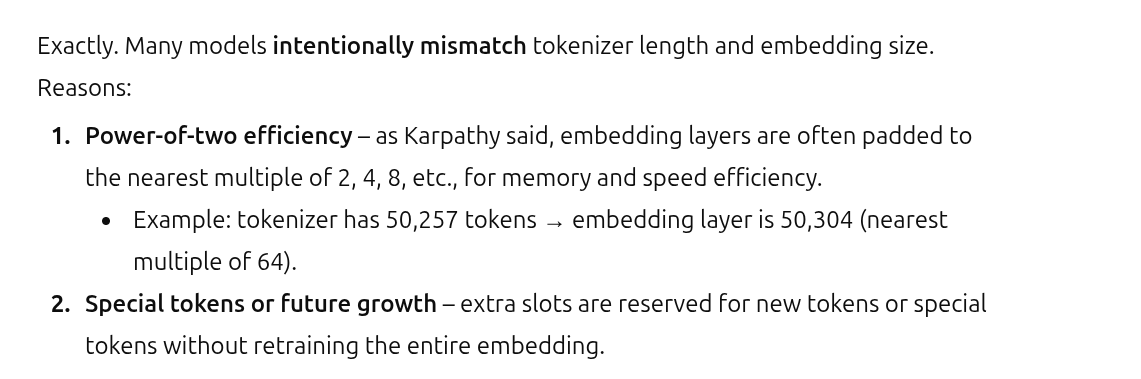

In [13]:
sorted(tokenizer_phi.vocab.items(), key = lambda t: -t[1])[:11] #t[1] is the token id. , -t[1] flips the order for sortin 

## means sorts the pair by id in decendingg order because of - 

[('<|user|>', 32010),
 ('<|placeholder6|>', 32009),
 ('<|placeholder5|>', 32008),
 ('<|end|>', 32007),
 ('<|system|>', 32006),
 ('<|placeholder4|>', 32005),
 ('<|placeholder3|>', 32004),
 ('<|placeholder2|>', 32003),
 ('<|placeholder1|>', 32002),
 ('<|assistant|>', 32001),
 ('<|endoftext|>', 32000)]

In [16]:
tokenizer_phi.eos_token , tokenizer_phi.eos_token_id

('<|endoftext|>', 32000)

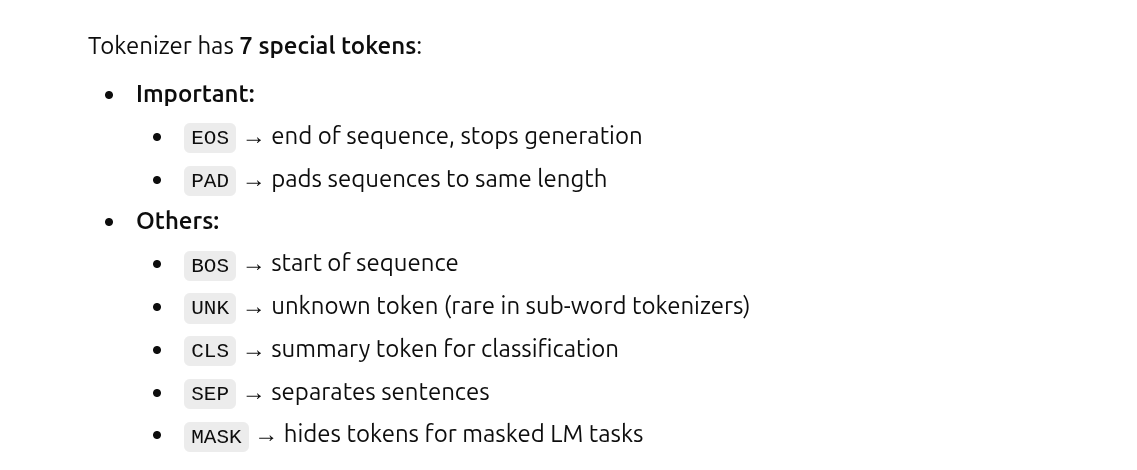

In [17]:
tokenizer_phi.all_special_tokens

['<s>', '<|endoftext|>', '<unk>']

In [18]:
tokenizer_phi.special_tokens_map

{'bos_token': '<s>',
 'eos_token': '<|endoftext|>',
 'unk_token': '<unk>',
 'pad_token': '<|endoftext|>'}

In [21]:
(tokenizer_phi.cls_token, tokenizer_phi.sep_token, tokenizer_phi.mask_token)

(None, None, None)

left vs right padding